In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

image_dir = Path("../data/Image")
mask_dir = Path("../data/Mask")

images = sorted(image_dir.glob("*"))
masks = sorted(mask_dir.glob("*"))

print("Images:", len(images))
print("Masks:", len(masks))

c:\Users\User\Desktop\Projects\flood disaster response\notebooks
Images: 290
Masks: 290


In [11]:
for image, mask in zip(images, masks):
    assert image.stem == mask.stem, f"Mismatch: {image} vs {mask}"

print("All image-mask pairs match.")

All image-mask pairs match.


In [12]:
from PIL import Image

for path in images[:10]:
    img = Image.open(path)
    print(path.name, img.size, img.mode)

0.jpg (893, 551) P
1.jpg (500, 300) RGB
10.jpg (1200, 900) RGB
1000.jpg (2100, 1367) RGB
1001.jpg (982, 726) RGB
1002.jpg (929, 523) RGB
1003.jpg (1200, 676) RGB
1004.jpg (2100, 1400) RGB
1005.jpg (630, 418) RGB
1006.jpg (700, 394) RGB


In [ ]:
    for path in masks[:10]:
        mask = Image.open(path)
        print(path.name, mask.size, mask.mode)

0.png (893, 551) L
1.png (500, 300) L
10.png (1200, 900) L
1000.png (2100, 1367) L
1001.png (982, 726) L
1002.png (929, 523) L
1003.png (1200, 676) L
1004.png (2100, 1400) L
1005.png (630, 418) L
1006.png (700, 394) L


In [14]:
mask = np.array(Image.open(masks[0]))

print(np.unique(mask))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

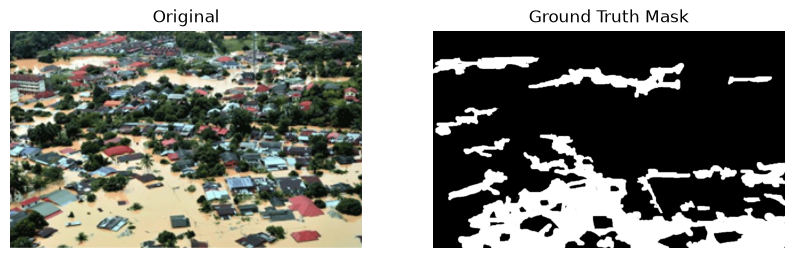

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

image = Image.open(images[0])
mask = Image.open(masks[0])

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [16]:
import numpy as np
from PIL import Image

mask = np.array(Image.open(masks[0]))

flood_pixels = np.sum(mask > 0)
total_pixels = mask.size

percentage = flood_pixels / total_pixels * 100

print(f"Flooded pixels: {percentage:.2f}%")

Flooded pixels: 26.44%


In [18]:
mask = np.array(Image.open(masks[0]))

print("Min:", mask.min())
print("Max:", mask.max())
print("Unique values:", len(np.unique(mask)))

print("Most common values:")

values, counts = np.unique(mask, return_counts=True)

for value, count in zip(values, counts):
    print(value, count)

Min: 0
Max: 255
Unique values: 256
Most common values:
0 361968
1 109
2 205
3 174
4 157
5 172
6 105
7 236
8 144
9 102
10 148
11 111
12 79
13 92
14 254
15 101
16 169
17 55
18 87
19 67
20 66
21 79
22 99
23 35
24 59
25 44
26 32
27 117
28 137
29 53
30 45
31 71
32 57
33 33
34 54
35 35
36 16
37 26
38 30
39 8
40 58
41 68
42 76
43 59
44 21
45 8
46 31
47 19
48 48
49 8
50 15
51 13
52 6
53 71
54 95
55 77
56 121
57 88
58 30
59 54
60 32
61 41
62 45
63 99
64 185
65 16
66 20
67 30
68 26
69 53
70 24
71 32
72 80
73 25
74 15
75 12
76 18
77 43
78 21
79 19
80 61
81 22
82 24
83 29
84 32
85 77
86 106
87 35
88 15
89 13
90 11
91 11
92 30
93 25
94 52
95 39
96 56
97 7
98 38
99 17
100 35
101 20
102 23
103 31
104 21
105 10
106 52
107 39
108 62
109 39
110 18
111 22
112 64
113 27
114 43
115 24
116 55
117 44
118 19
119 15
120 50
121 44
122 19
123 60
124 48
125 61
126 24
127 175
128 240
129 18
130 23
131 21
132 41
133 59
134 21
135 24
136 19
137 44
138 27
139 17
140 51
141 21
142 57
143 61
144 64
145 21
146 29
147 59

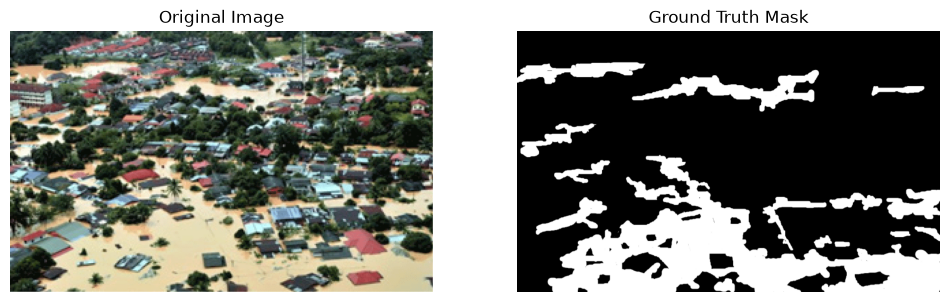

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

image = Image.open(images[0])
mask = Image.open(masks[0])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [21]:
import numpy as np

mask_array = np.array(mask)

print("Pixels == 0:", np.sum(mask_array == 0))
print("Pixels == 255:", np.sum(mask_array == 255))
print("Pixels between 1 and 254:", np.sum((mask_array > 0) & (mask_array < 255)))

print("Total pixels:", mask_array.size)

Pixels == 0: 361968
Pixels == 255: 114928
Pixels between 1 and 254: 15147
Total pixels: 492043
